In [1]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True 
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, backend as K 
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import gc

2026-04-08 18:16:16.786784: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775672176.961789      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775672177.014089      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775672177.426529      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775672177.426574      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775672177.426577      24 computation_placer.cc:177] computation placer alr

In [2]:
DATA_DIR = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset/"
ANN_DIR = "/kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations/embryo_dataset_annotations"

In [3]:
if os.path.exists(DATA_DIR):
    embryo_folders = [f for f in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, f))]
    print(f"Found {len(embryo_folders)} embryo folders")
    print(f"   First 5: {embryo_folders[:5]}")
else:
    print(f" DATA_DIR not found: {DATA_DIR}")

if os.path.exists(ANN_DIR):
    ann_files = [f for f in os.listdir(ANN_DIR) if f.endswith('.csv')]
    print(f"Found {len(ann_files)} annotation files")
    print(f"   First 5: {ann_files[:5]}")
    if ann_files:
        ann_path = os.path.join(ANN_DIR, ann_files[0])
        df = pd.read_csv(ann_path)
        print(f"\nSample annotation structure:")
        print(f"Shape: {df.shape}")

Found 704 embryo folders
   First 5: ['FM1017-5', 'HC459-6', 'GJ191-1', 'LMMG218-1-10', 'RD1142-2']
Found 704 annotation files
   First 5: ['BC750-7_phases.csv', 'SK308-7_phases.csv', 'QC697-4_phases.csv', 'DI358-3_phases.csv', 'DV210-4_phases.csv']

Sample annotation structure:
Shape: (13, 3)


In [4]:
PHASES = [
    'tPB2','tPNa','tPNf','t2','t3','t4','t5','t6','t7','t8','t9+',
    'tM','tSB','tB','tEB','tHB'
]
label_map = {p:i for i,p in enumerate(PHASES)}

In [5]:
def custom_embryo_loss(y_true, y_pred):
    alpha = 0.1
    num_classes = 16

    y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

    # 1: Standard Cross-Entropy
    ce_loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    # 2: Soft expected predicted class (differentiable)
    class_indices = tf.cast(tf.range(num_classes), tf.float32)
    y_pred_expected = tf.reduce_sum(y_pred * class_indices, axis=-1)

    # 3: Normalized squared distance penalty
    y_true_float = tf.cast(y_true, tf.float32)
    distance_penalty = alpha * tf.square(y_true_float - y_pred_expected) / (num_classes ** 2)

    return tf.reduce_mean(ce_loss + distance_penalty)

In [6]:
def build_dataframe(sample_rate=10):
    data = []
    ann_files = sorted([f for f in os.listdir(ANN_DIR) if f.endswith(".csv")])
    
    for file in tqdm(ann_files, desc="Processing Embryos"):
        embryo_id = file.replace("_phases.csv", "")
        img_folder = os.path.join(DATA_DIR, embryo_id)
        
        if not os.path.exists(img_folder): continue
        images = sorted([f for f in os.listdir(img_folder) 
                    if f.lower().endswith(('.jpg', '.png', '.jpeg', '.tiff'))])
  
        df_ann = pd.read_csv(os.path.join(ANN_DIR, file), header=None)
        df_ann.columns = ["phase", "start", "end"]
        
        for _, row in df_ann.iterrows():
            phase_name = row["phase"]
            if phase_name in label_map:
                label = label_map[phase_name]
                start, end = int(row["start"]), int(row["end"])
                
                frames = list(range(start, end, sample_rate))
                if len(frames) == 0 and start < end:
                    frames = [start]
                
                for f in frames:
                    if f < len(images):
                        img_path = os.path.join(img_folder, images[f])
                        data.append([img_path, label, embryo_id, phase_name])
                        
    return pd.DataFrame(data, columns=["image", "label", "embryo", "phase_name"])

In [7]:
master_df = build_dataframe(sample_rate=10)

Processing Embryos: 100%|██████████| 704/704 [01:22<00:00,  8.58it/s]


In [8]:
batch_size = 32
target_size = (224, 224)
num_classes = 16

In [9]:
unique_embryos = master_df['embryo'].unique()

# This is to get 16 classes in validation set
for seed in [42, 101, 7, 123]:
    train_ids, temp_ids = train_test_split(unique_embryos, test_size=0.3, random_state=seed)
    val_ids, test_ids = train_test_split(temp_ids, test_size=0.5, random_state=seed)

    train_df = master_df[master_df['embryo'].isin(train_ids)]
    val_df = master_df[master_df['embryo'].isin(val_ids)]
    test_df = master_df[master_df['embryo'].isin(test_ids)]
  
    if len(val_df['label'].unique()) == 16:
        print(f"✅ Found stable split with seed {seed}")
        break

✅ Found stable split with seed 7


In [10]:
train_df = master_df[master_df['embryo'].isin(train_ids)].copy()
val_df = master_df[master_df['embryo'].isin(val_ids)].copy()
test_df = master_df[master_df['embryo'].isin(test_ids)].copy()

train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df, x_col='image', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='sparse', shuffle=True
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df, x_col='image', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='sparse', shuffle=False
)

test_generator = datagen.flow_from_dataframe(
    dataframe=test_df, x_col='image', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='sparse', shuffle=False
)

# Final Print Summary
print(f"\nTraining Classes:   {len(np.unique(train_generator.classes))}")
print(f"Validation Classes: {len(np.unique(val_generator.classes))}")
print(f"Testing Classes:    {len(np.unique(test_generator.classes))}")

Found 23384 validated image filenames belonging to 16 classes.
Found 4936 validated image filenames belonging to 16 classes.
Found 4732 validated image filenames belonging to 16 classes.

Training Classes:   16
Validation Classes: 16
Testing Classes:    16


In [11]:
# INCEPTION V1 ARCHITECTURE 
def inception_module(x, f1, f3r, f3, f5r, f5, fp):
    p1 = layers.Conv2D(f1, (1, 1), padding='same', activation='relu')(x)
    p2 = layers.Conv2D(f3r, (1, 1), padding='same', activation='relu')(x)
    p2 = layers.Conv2D(f3, (3, 3), padding='same', activation='relu')(p2)
    p3 = layers.Conv2D(f5r, (1, 1), padding='same', activation='relu')(x)
    p3 = layers.Conv2D(f5, (5, 5), padding='same', activation='relu')(p3)
    p4 = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    p4 = layers.Conv2D(fp, (1, 1), padding='same', activation='relu')(p4)
    
    return layers.Concatenate()([p1, p2, p3, p4])

def build_inception_v1(input_shape=(224, 224, 3), num_classes=16):
    inputs = tf.keras.layers.Input(shape=input_shape)
    x = tf.keras.layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.models.Model(inputs, outputs)

In [12]:
if not os.path.exists('embryo_results'):
    os.makedirs('embryo_results')
results_summary = []

In [13]:
def train_and_save(name, model, loss_name, loss_type):
    print(f"TRAINING: {name} | LOSS: {loss_name}")
    
    # Compile model
    model.compile(optimizer=optimizers.Adam(0.001), 
                  loss=loss_type, 
                  metrics=['accuracy'])
    
    callbacks = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    
    history = model.fit(train_generator, validation_data=val_generator, epochs=15, callbacks=callbacks, verbose=1)
    
    model.save(f'embryo_results/{name}_{loss_name.replace(" ", "_")}_model.h5')
    
    hist_df = pd.DataFrame(history.history)
    hist_df.to_csv(f'embryo_results/{name}_{loss_name.replace(" ", "_")}_history.csv', index=False)
    
    # Plot training curves
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(hist_df['loss'], label='Train Loss')
    plt.plot(hist_df['val_loss'], label='Validation Loss')
    plt.title(f'{name} - {loss_name}\nLoss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(hist_df['accuracy'], label='Train Accuracy')
    plt.plot(hist_df['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{name} - {loss_name}\nAccuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'embryo_results/{name}_{loss_name.replace(" ", "_")}_curves.png', dpi=100)
    plt.show()

    plt.close()
    print(f"TESTING {name} - {loss_name} on Test Set")
    
    test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
   
    predictions = model.predict(test_generator, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = test_generator.classes

    report = classification_report(true_classes, predicted_classes, 
                                   target_names=PHASES, 
                                   output_dict=True)
    print("\nClassification Report:")
    print(report)
    # Print results
    print(f" RESULTS FOR {name} - {loss_name}")
    print(f" Best Validation Accuracy: {max(history.history['val_accuracy']):.4f} ({max(history.history['val_accuracy'])*100:.2f}%)")
    print(f" Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f} ({history.history['val_accuracy'][-1]*100:.2f}%)")
    print(f" Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f" Test Loss: {test_loss:.4f}")
    
    # Store results
    results_summary.append({
        'Model': name,
        'Loss_Function': loss_name,
        'Best_Val_Accuracy': max(history.history['val_accuracy']),
        'Final_Val_Accuracy': history.history['val_accuracy'][-1],
        'Test_Accuracy': test_accuracy,
        'Test_Loss': test_loss,
        'Best_Val_Loss': min(history.history['val_loss']),
        'Final_Val_Loss': history.history['val_loss'][-1],
        'Best_Epoch': np.argmax(history.history['val_accuracy']) + 1,
        'Total_Epochs': len(history.history['accuracy'])
    })
    
    test_results_df = pd.DataFrame([{
        'Model': name,
        'Loss_Function': loss_name,
        'Test_Accuracy': test_accuracy,
        'Test_Loss': test_loss
    }])
    test_results_df.to_csv(f'embryo_results/{name}_{loss_name.replace(" ", "_")}_test_results.csv', index=False)
    
    # Clear memory
    tf.keras.backend.clear_session()
    gc.collect()
    
    return history, model, test_accuracy

I0000 00:00:1775672317.266512      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
TRAINING: MobileNetV1 | LOSS: Normal Loss


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1775672326.256991      70 service.cc:152] XLA service 0x7f6dc4004220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775672326.257047      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775672326.952252      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775672331.902436      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


731/731 ━━━━━━━━━━━━━━━━━━━━ 258s 340ms/step - accuracy: 0.2925 - loss: 2.1658 - val_accuracy: 0.3489 - val_loss: 1.9552
Epoch 2/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 84s 115ms/step - accuracy: 0.3640 - loss: 1.8193 - val_accuracy: 0.3547 - val_loss: 1.9213
Epoch 3/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.3934 - loss: 1.7427 - val_accuracy: 0.3527 - val_loss: 1.9858
Epoch 4/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 90s 124ms/step - accuracy: 0.4095 - loss: 1.6788 - val_accuracy: 0.3365 - val_loss: 1.9445
Epoch 5/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 80s 110ms/step - accuracy: 0.4292 - loss: 1.6274 - val_accuracy: 0.3509 - val_loss: 1.9585
Epoch 6/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.4408 - loss: 1.5797 - val_accuracy: 0.3402 - val_loss: 2.0394
Epoch 7/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 90s 123ms/step - accuracy: 0.4596 - loss: 1.5300 - val_accuracy: 0.3501 - val_loss: 1.9932
Epoch 8/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 91s 125ms/step - accuracy: 0.4723 - loss: 1.4875 - va

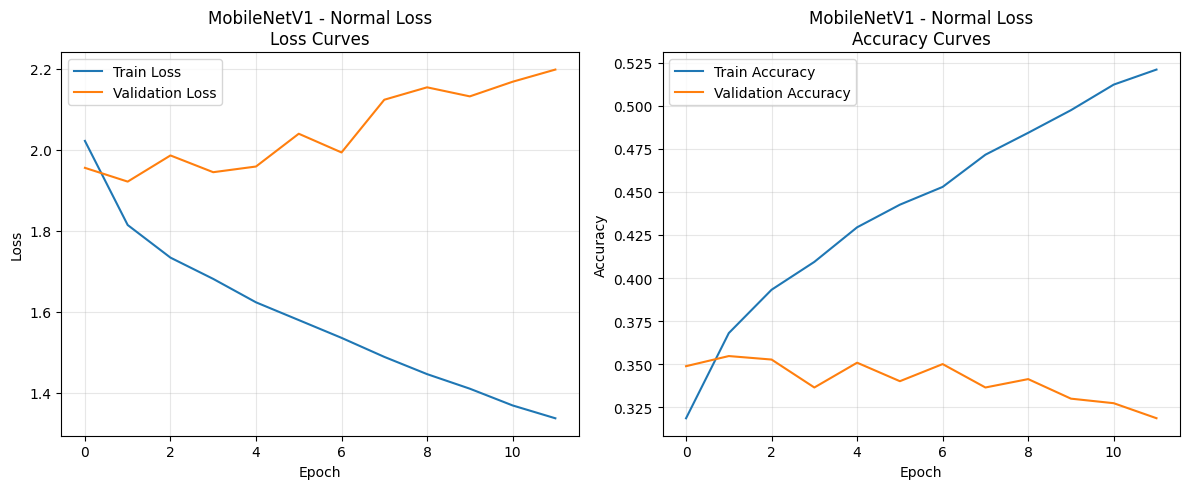

TESTING MobileNetV1 - Normal Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 48s 324ms/step - accuracy: 0.3270 - loss: 1.9383


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 1.0, 'recall': 0.005555555555555556, 'f1-score': 0.011049723756906077, 'support': 180.0}, 'tPNa': {'precision': 0.45918367346938777, 'recall': 0.6053811659192825, 'f1-score': 0.5222437137330754, 'support': 669.0}, 'tPNf': {'precision': 0.3100401606425703, 'recall': 0.5398601398601398, 'f1-score': 0.39387755102040817, 'support': 715.0}, 't2': {'precision': 0.24074074074074073, 'recall': 0.3236514522821577, 'f1-score': 0.2761061946902655, 'support': 241.0}, 't3': {'precision': 0.30409356725146197, 'recall': 0.20717131474103587, 'f1-score': 0.24644549763033174, 'support': 251.0}, 't4': {'precision': 0.18032786885245902, 'recall': 0.07801418439716312, 'f1-score': 0.10891089108910891, 'support': 141.0}, 't5': {'precision': 0.26595744680851063, 'recall': 0.26785714285714285, 'f1-score': 0.2669039145907473, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-scor

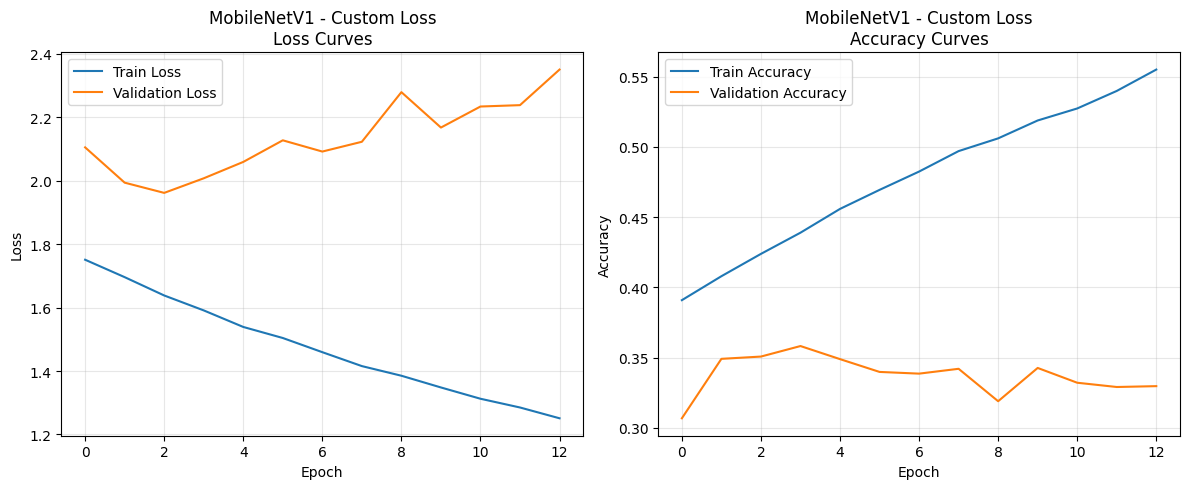

TESTING MobileNetV1 - Custom Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.3432 - loss: 1.9516


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.18181818181818182, 'recall': 0.044444444444444446, 'f1-score': 0.07142857142857142, 'support': 180.0}, 'tPNa': {'precision': 0.3868402024584237, 'recall': 0.7997010463378177, 'f1-score': 0.5214424951267057, 'support': 669.0}, 'tPNf': {'precision': 0.44561933534743203, 'recall': 0.4125874125874126, 'f1-score': 0.42846768336964414, 'support': 715.0}, 't2': {'precision': 0.3383838383838384, 'recall': 0.27800829875518673, 'f1-score': 0.3052391799544419, 'support': 241.0}, 't3': {'precision': 0.41843971631205673, 'recall': 0.2350597609561753, 'f1-score': 0.3010204081632653, 'support': 251.0}, 't4': {'precision': 0.20149253731343283, 'recall': 0.19148936170212766, 'f1-score': 0.19636363636363635, 'support': 141.0}, 't5': {'precision': 0.22413793103448276, 'recall': 0.4642857142857143, 'f1-score': 0.3023255813953488, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0

(<keras.src.callbacks.history.History at 0x7f6e8c1c4260>,
 <Functional name=functional, built=True>,
 0.3412933349609375)

In [14]:
# Normal Loss
base = tf.keras.applications.MobileNet(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False
model = models.Model(base.input, layers.Dense(16, activation='softmax')(layers.Dense(512, activation='relu')(layers.GlobalAveragePooling2D()(base.output))))
train_and_save('MobileNetV1', model, 'Normal Loss', 'sparse_categorical_crossentropy')

# Custom Loss
model_c = tf.keras.models.clone_model(model)
model_c.build((None, 224, 224, 3))
model_c.set_weights(model.get_weights())
train_and_save('MobileNetV1', model_c, 'Custom Loss', custom_embryo_loss)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
TRAINING: MobileNetV2 | LOSS: Normal Loss
Epoch 1/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 106s 132ms/step - accuracy: 0.2817 - loss: 2.2090 - val_accuracy: 0.3169 - val_loss: 2.0658
Epoch 2/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 83s 114ms/step - accuracy: 0.3541 - loss: 1.8944 - val_accuracy: 0.3225 - val_loss: 2.0284
Epoch 3/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 85s 116ms/step - accuracy: 0.3822 - loss: 1.7836 - val_accuracy: 0.3002 - val_loss: 2.0584
Epoch 4/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.4026 - loss: 1.7053 - val_accuracy: 0.3331 - val_loss: 2.0307
Epoch 5/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.4293 - loss: 1.6297 - val_accuracy: 0.3156 - val_loss: 2.0771
Epoch 6/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 87s 118ms/step - accuracy: 0.4462 - loss: 1.5615 - val_accuracy: 0.3187 - val_loss: 2.1290
Epoch 7/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 81s 111ms/step - accuracy: 0.4661 - loss: 1.5110 - val_accuracy: 0.3055 - val_loss

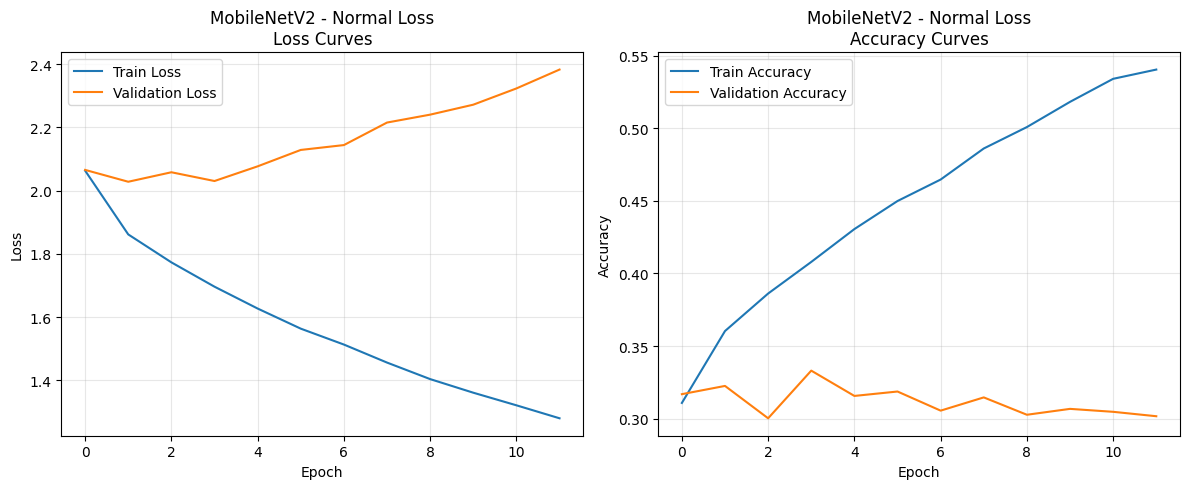

TESTING MobileNetV2 - Normal Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.3068 - loss: 1.9810


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.3678357570573139, 'recall': 0.6427503736920778, 'f1-score': 0.46789989118607184, 'support': 669.0}, 'tPNf': {'precision': 0.4166666666666667, 'recall': 0.45454545454545453, 'f1-score': 0.43478260869565216, 'support': 715.0}, 't2': {'precision': 0.267515923566879, 'recall': 0.17427385892116182, 'f1-score': 0.21105527638190955, 'support': 241.0}, 't3': {'precision': 0.2754491017964072, 'recall': 0.3665338645418327, 'f1-score': 0.3145299145299145, 'support': 251.0}, 't4': {'precision': 0.15217391304347827, 'recall': 0.04964539007092199, 'f1-score': 0.0748663101604278, 'support': 141.0}, 't5': {'precision': 0.22736030828516376, 'recall': 0.42142857142857143, 'f1-score': 0.295369211514393, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'pr

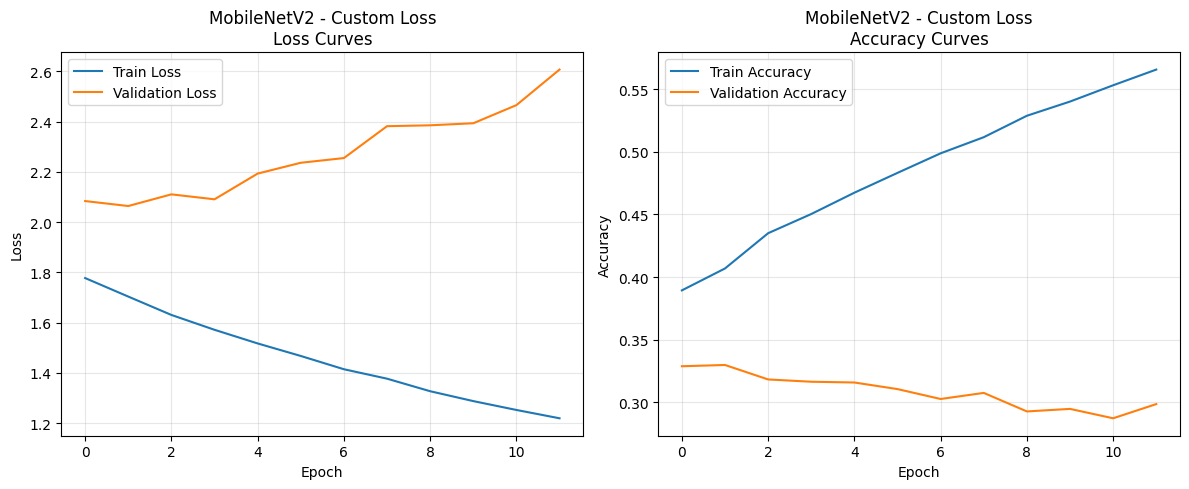

TESTING MobileNetV2 - Custom Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 17s 114ms/step - accuracy: 0.3314 - loss: 2.0005


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.4402125775022144, 'recall': 0.7428998505231689, 'f1-score': 0.5528364849833148, 'support': 669.0}, 'tPNf': {'precision': 0.3525963149078727, 'recall': 0.5888111888111888, 'f1-score': 0.4410686223153483, 'support': 715.0}, 't2': {'precision': 0.3082706766917293, 'recall': 0.17012448132780084, 'f1-score': 0.2192513368983957, 'support': 241.0}, 't3': {'precision': 0.2757201646090535, 'recall': 0.26693227091633465, 'f1-score': 0.27125506072874495, 'support': 251.0}, 't4': {'precision': 0.13157894736842105, 'recall': 0.1773049645390071, 'f1-score': 0.1510574018126888, 'support': 141.0}, 't5': {'precision': 0.24705882352941178, 'recall': 0.375, 'f1-score': 0.2978723404255319, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'precision': 0.329

(<keras.src.callbacks.history.History at 0x7f6e8c2812e0>,
 <Functional name=functional, built=True>,
 0.34509721398353577)

In [15]:
# Normal Loss
base = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False
model = models.Model(base.input, layers.Dense(16, activation='softmax')(layers.Dense(512, activation='relu')(layers.GlobalAveragePooling2D()(base.output))))
train_and_save('MobileNetV2', model, 'Normal Loss', 'sparse_categorical_crossentropy')

# Custom Loss
model_c = tf.keras.models.clone_model(model)
model_c.build((None, 224, 224, 3)) 
model_c.set_weights(model.get_weights()) 
train_and_save('MobileNetV2', model_c, 'Custom Loss', custom_embryo_loss)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
TRAINING: VGG16 | LOSS: Normal Loss
Epoch 1/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 105s 132ms/step - accuracy: 0.2356 - loss: 2.3678 - val_accuracy: 0.2970 - val_loss: 2.1174
Epoch 2/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 86s 117ms/step - accuracy: 0.3072 - loss: 2.0675 - val_accuracy: 0.3006 - val_loss: 2.0742
Epoch 3/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 87s 119ms/step - accuracy: 0.3258 - loss: 1.9903 - val_accuracy: 0.3114 - val_loss: 2.0484
Epoch 4/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - accuracy: 0.3333 - loss: 1.9642 - val_accuracy: 0.3225 - val_loss: 2.0344
Epoch 5/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - accuracy: 0.3428 - loss: 1.9242 - val_accuracy: 0.3165 - val_loss: 2.0141
Epoch 6/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 89s 121ms/step - accuracy: 0.3476 - loss: 1.9035 - val_accuracy: 0.3292 - val_loss: 2.0488
Epoch 7/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 91s 124ms/step - accuracy: 0.3536 - loss: 1.8806 - val_accuracy: 0.3162 - val_loss: 2.

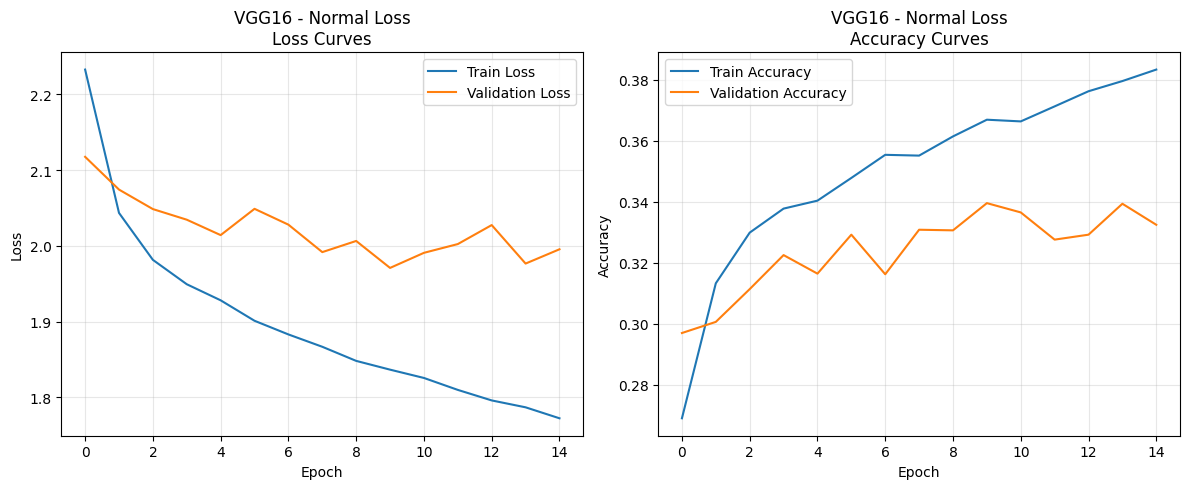

TESTING VGG16 - Normal Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.3460 - loss: 1.9351


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.4373913043478261, 'recall': 0.7518684603886397, 'f1-score': 0.5530511269928532, 'support': 669.0}, 'tPNf': {'precision': 0.3928944618599791, 'recall': 0.5258741258741259, 'f1-score': 0.44976076555023925, 'support': 715.0}, 't2': {'precision': 0.4027777777777778, 'recall': 0.12033195020746888, 'f1-score': 0.1853035143769968, 'support': 241.0}, 't3': {'precision': 0.5084745762711864, 'recall': 0.23904382470119523, 'f1-score': 0.3252032520325203, 'support': 251.0}, 't4': {'precision': 0.14102564102564102, 'recall': 0.07801418439716312, 'f1-score': 0.1004566210045662, 'support': 141.0}, 't5': {'precision': 0.19141914191419143, 'recall': 0.6214285714285714, 'f1-score': 0.2926829268292683, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'pre

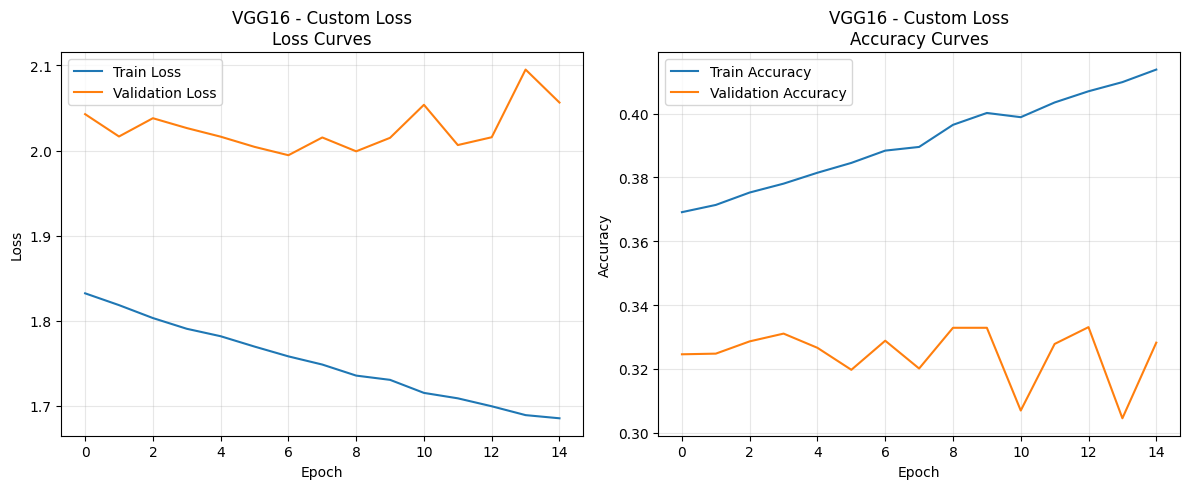

TESTING VGG16 - Custom Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.3386 - loss: 1.9503


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.38273283480625425, 'recall': 0.8415545590433483, 'f1-score': 0.5261682242990654, 'support': 669.0}, 'tPNf': {'precision': 0.39665354330708663, 'recall': 0.5636363636363636, 'f1-score': 0.4656268053148469, 'support': 715.0}, 't2': {'precision': 0.2857142857142857, 'recall': 0.23236514522821577, 'f1-score': 0.2562929061784897, 'support': 241.0}, 't3': {'precision': 0.2511013215859031, 'recall': 0.22709163346613545, 'f1-score': 0.2384937238493724, 'support': 251.0}, 't4': {'precision': 0.16981132075471697, 'recall': 0.1276595744680851, 'f1-score': 0.145748987854251, 'support': 141.0}, 't5': {'precision': 0.24149659863945577, 'recall': 0.25357142857142856, 'f1-score': 0.24738675958188153, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'pr

(<keras.src.callbacks.history.History at 0x7f6d9839ab70>,
 <Functional name=functional, built=True>,
 0.33981403708457947)

In [16]:
# Normal Loss
base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False
model = models.Model(base.input, layers.Dense(16, activation='softmax')(layers.Dense(512, activation='relu')(layers.GlobalAveragePooling2D()(base.output))))
train_and_save('VGG16', model, 'Normal Loss', 'sparse_categorical_crossentropy')

# Custom Loss
model_c = tf.keras.models.clone_model(model)
model_c.build((None, 224, 224, 3))
model_c.set_weights(model.get_weights())  
train_and_save('VGG16', model_c, 'Custom Loss', custom_embryo_loss)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
TRAINING: VGG19 | LOSS: Normal Loss
Epoch 1/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 96s 128ms/step - accuracy: 0.2222 - loss: 2.4217 - val_accuracy: 0.2838 - val_loss: 2.1534
Epoch 2/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 88s 120ms/step - accuracy: 0.2971 - loss: 2.1078 - val_accuracy: 0.2974 - val_loss: 2.1417
Epoch 3/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.3184 - loss: 2.0245 - val_accuracy: 0.3057 - val_loss: 2.0581
Epoch 4/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.3280 - loss: 1.9904 - val_accuracy: 0.3118 - val_loss: 2.0691
Epoch 5/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 95s 130ms/step - accuracy: 0.3340 - loss: 1.9685 - val_accuracy: 0.3205 - val_loss: 2.0441
Epoch 6/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 91s 124ms/step - accuracy: 0.3305 - loss: 1.9594 - val_accuracy: 0.3239 - val_loss: 2.0358
Epoch 7/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 86s 118ms/step - accuracy: 0.3370 - loss: 1.9402 - val_accuracy: 0.3134 - val_loss: 2.0

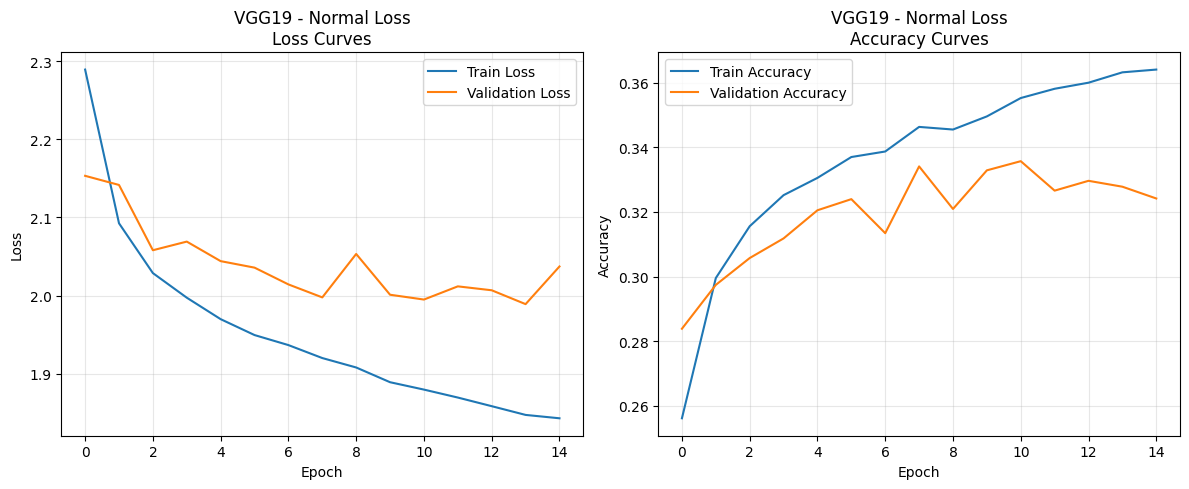

TESTING VGG19 - Normal Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.3335 - loss: 1.9781


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.3869760479041916, 'recall': 0.772795216741405, 'f1-score': 0.5157107231920199, 'support': 669.0}, 'tPNf': {'precision': 0.44473684210526315, 'recall': 0.4727272727272727, 'f1-score': 0.4583050847457627, 'support': 715.0}, 't2': {'precision': 0.4246575342465753, 'recall': 0.12863070539419086, 'f1-score': 0.19745222929936307, 'support': 241.0}, 't3': {'precision': 0.4097222222222222, 'recall': 0.2350597609561753, 'f1-score': 0.29873417721518986, 'support': 251.0}, 't4': {'precision': 0.13636363636363635, 'recall': 0.02127659574468085, 'f1-score': 0.03680981595092025, 'support': 141.0}, 't5': {'precision': 0.20337197049525815, 'recall': 0.6892857142857143, 'f1-score': 0.3140764849471115, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'pr

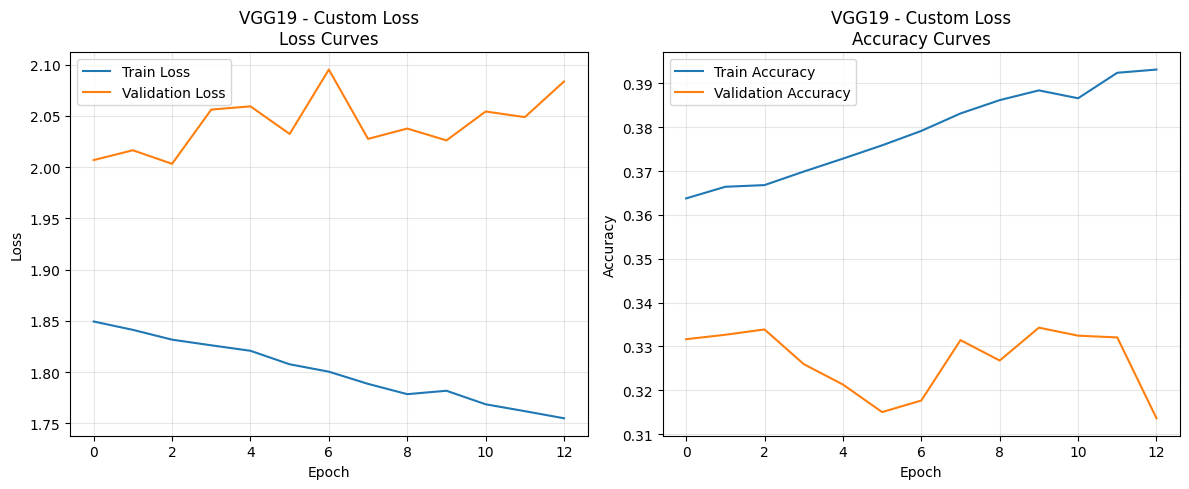

TESTING VGG19 - Custom Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.3361 - loss: 1.9673


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.39386602098466506, 'recall': 0.7294469357249627, 'f1-score': 0.5115303983228512, 'support': 669.0}, 'tPNf': {'precision': 0.3213793103448276, 'recall': 0.6517482517482518, 'f1-score': 0.43048498845265587, 'support': 715.0}, 't2': {'precision': 0.375, 'recall': 0.08713692946058091, 'f1-score': 0.1414141414141414, 'support': 241.0}, 't3': {'precision': 0.33884297520661155, 'recall': 0.16334661354581673, 'f1-score': 0.22043010752688172, 'support': 251.0}, 't4': {'precision': 0.08333333333333333, 'recall': 0.02127659574468085, 'f1-score': 0.03389830508474576, 'support': 141.0}, 't5': {'precision': 0.3079584775086505, 'recall': 0.31785714285714284, 'f1-score': 0.31282952548330406, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'precision':

(<keras.src.callbacks.history.History at 0x7f6d8cf0bcb0>,
 <Functional name=functional, built=True>,
 0.3360101580619812)

In [17]:
# Normal Loss 
base_vgg19 = tf.keras.applications.VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_vgg19.trainable = False

x = layers.GlobalAveragePooling2D()(base_vgg19.output)
x = layers.Dense(512, activation='relu')(x)
out = layers.Dense(16, activation='softmax')(x)
model_vgg19 = models.Model(base_vgg19.input, out)
train_and_save('VGG19', model_vgg19, 'Normal Loss', 'sparse_categorical_crossentropy')

# Custom Loss
model_vgg19_custom = tf.keras.models.clone_model(model_vgg19)
model_vgg19_custom.build((None, 224, 224, 3)) 
model_vgg19_custom.set_weights(model_vgg19.get_weights()) 
train_and_save('VGG19', model_vgg19_custom, 'Custom Loss', custom_embryo_loss)

TRAINING: InceptionV1 | LOSS: Normal Loss
Epoch 1/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 109s 132ms/step - accuracy: 0.1597 - loss: 2.5556 - val_accuracy: 0.1582 - val_loss: 2.5393
Epoch 2/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 88s 120ms/step - accuracy: 0.1710 - loss: 2.5262 - val_accuracy: 0.2022 - val_loss: 2.4602
Epoch 3/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 91s 124ms/step - accuracy: 0.2366 - loss: 2.3432 - val_accuracy: 0.2559 - val_loss: 2.2347
Epoch 4/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 87s 120ms/step - accuracy: 0.2699 - loss: 2.2046 - val_accuracy: 0.2723 - val_loss: 2.1761
Epoch 5/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 84s 115ms/step - accuracy: 0.2846 - loss: 2.1325 - val_accuracy: 0.2881 - val_loss: 2.1374
Epoch 6/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 84s 115ms/step - accuracy: 0.2982 - loss: 2.0758 - val_accuracy: 0.3069 - val_loss: 2.0918
Epoch 7/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 83s 113ms/step - accuracy: 0.3066 - loss: 2.0436 - val_accuracy: 0.3152 - val_loss: 2.0638
Epoch 8/15
731/731 ━━━━━━━━━━━━━━━━━━━━ 

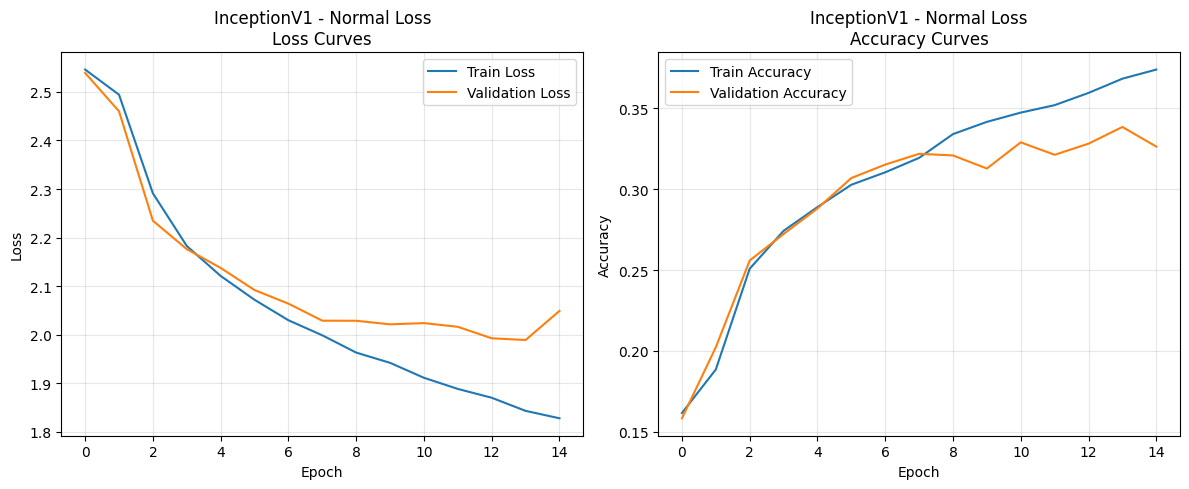

TESTING InceptionV1 - Normal Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.3183 - loss: 1.9695


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.34705882352941175, 'recall': 0.8819133034379671, 'f1-score': 0.49810046433094135, 'support': 669.0}, 'tPNf': {'precision': 0.37831858407079644, 'recall': 0.4783216783216783, 'f1-score': 0.4224830142063002, 'support': 715.0}, 't2': {'precision': 0.3135593220338983, 'recall': 0.15352697095435686, 'f1-score': 0.20612813370473537, 'support': 241.0}, 't3': {'precision': 0.2722222222222222, 'recall': 0.1952191235059761, 'f1-score': 0.2273781902552204, 'support': 251.0}, 't4': {'precision': 0.16923076923076924, 'recall': 0.15602836879432624, 'f1-score': 0.16236162361623616, 'support': 141.0}, 't5': {'precision': 0.21335807050092764, 'recall': 0.4107142857142857, 'f1-score': 0.28083028083028083, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {

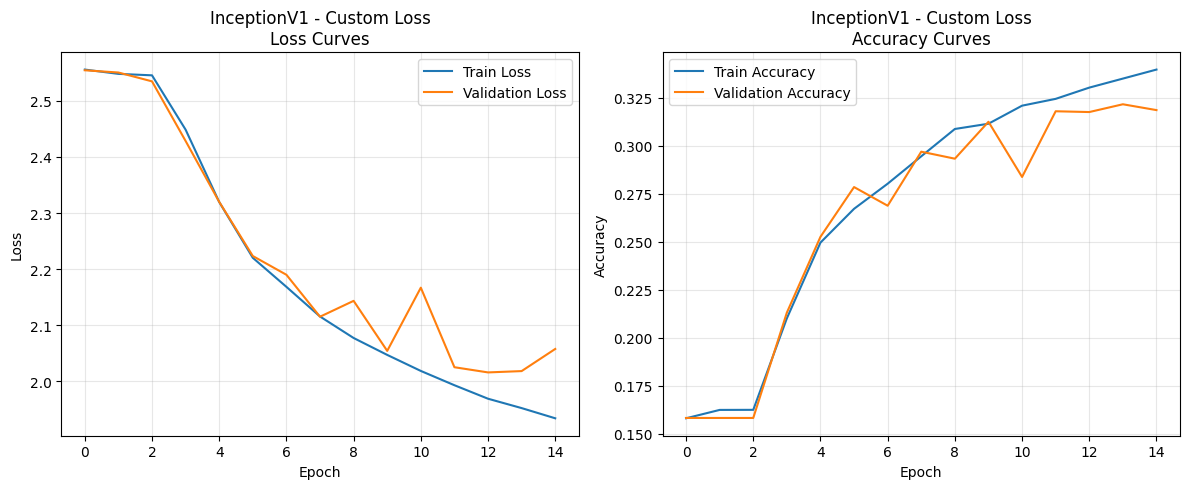

TESTING InceptionV1 - Custom Loss on Test Set
148/148 ━━━━━━━━━━━━━━━━━━━━ 18s 122ms/step - accuracy: 0.3111 - loss: 2.0147


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification Report:
{'tPB2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 180.0}, 'tPNa': {'precision': 0.3286549707602339, 'recall': 0.8400597907324364, 'f1-score': 0.4724674232870954, 'support': 669.0}, 'tPNf': {'precision': 0.366120218579235, 'recall': 0.5622377622377622, 'f1-score': 0.44346387203530063, 'support': 715.0}, 't2': {'precision': 0.3709677419354839, 'recall': 0.0954356846473029, 'f1-score': 0.15181518151815182, 'support': 241.0}, 't3': {'precision': 0.30851063829787234, 'recall': 0.11553784860557768, 'f1-score': 0.1681159420289855, 'support': 251.0}, 't4': {'precision': 0.10948905109489052, 'recall': 0.10638297872340426, 'f1-score': 0.1079136690647482, 'support': 141.0}, 't5': {'precision': 0.21157684630738524, 'recall': 0.37857142857142856, 'f1-score': 0.2714468629961588, 'support': 280.0}, 't6': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 4.0}, 't7': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 127.0}, 't8': {'pr

(<keras.src.callbacks.history.History at 0x7f6d8e7ba960>,
 <Functional name=functional, built=True>,
 0.3117075264453888)

In [18]:
# Normal Loss
model_inc_normal = build_inception_v1(input_shape=(224, 224, 3), num_classes=16)
train_and_save('InceptionV1', model_inc_normal, 'Normal Loss', 'sparse_categorical_crossentropy')

# Custom Loss
model_inc_custom = build_inception_v1(input_shape=(224, 224, 3), num_classes=16)
train_and_save('InceptionV1', model_inc_custom, 'Custom Loss', custom_embryo_loss)

In [19]:
final_df = pd.DataFrame(results_summary)
final_df.to_csv('embryo_results/final_comparison_results.csv', index=False)
final_df

,Model,Loss_Function,Best_Val_Accuracy,Final_Val_Accuracy,Test_Accuracy,Test_Loss,Best_Val_Loss,Final_Val_Loss,Best_Epoch,Total_Epochs
0,MobileNetV1,Normal Loss,0.354741,0.318679,0.330516,1.927852,1.921254,2.197789,2,12
1,MobileNetV1,Custom Loss,0.358185,0.329619,0.341293,1.959972,1.961635,2.350389,4,13
2,MobileNetV2,Normal Loss,0.333063,0.301661,0.318259,1.975393,2.028365,2.383121,4,12
3,MobileNetV2,Custom Loss,0.329822,0.298622,0.345097,1.980018,2.064327,2.607341,2,12
4,VGG16,Normal Loss,0.339546,0.332455,0.347422,1.911939,1.970794,1.995376,10,15
5,VGG16,Custom Loss,0.333063,0.328201,0.339814,1.934594,1.994473,2.056355,13,15
6,VGG19,Normal Loss,0.335697,0.324149,0.333686,1.972221,1.989027,2.037260,11,15
7,VGG19,Custom Loss,0.334279,0.313614,0.336010,1.963512,2.003209,2.083527,10,13
8,InceptionV1,Normal Loss,0.338533,0.326378,0.321640,1.951431,1.988797,2.048773,14,15
9,InceptionV1,Custom Loss,0.321718,0.318679,0.311708,2.002650,2.015756,2.057585,14,15
